Sample afte feature Engineering: 
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  day_of_week  \
0           1            0                    5         224            5   
1           1            1                    1         348            5   
2           1            0                    6         249            6   
3           1            0                    7         259            6   
4           0            0                    3         277            0   

   month  year  is_month_end  
0      1  2022             0  
1      1

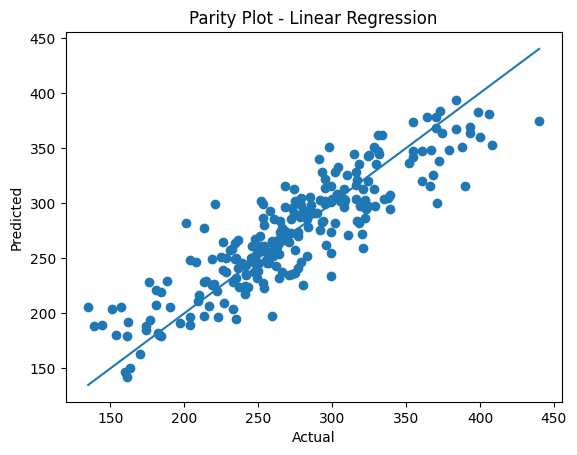

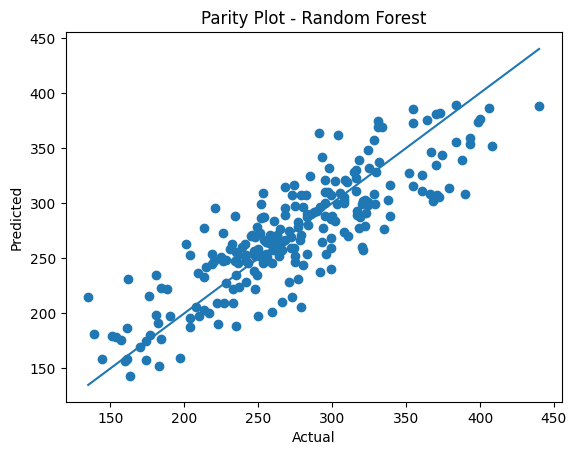


Top 5 Important Influential Features:
                feature  importance
3           is_festival    0.173356
18     store_size_small    0.166052
15  location_type_urban    0.108783
6           day_of_week    0.078710
2            is_weekend    0.068935


In [1]:
# -------------------------------
# Q3: FEATURE ENGINEERING AND REGRESSION PIPELINE
# -------------------------------

# Import necessary libraries
import pandas as pd
import numpy as np

# For preprocessing and pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# For plotting
import matplotlib.pyplot as plt

# Loading Dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Converting transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# ------------------------------
# STEP 1: DATE FEATURE ENGINEERING (Data Features)
# ------------------------------

# Extracting useful features from date
df["day_of_week"] = df["transaction_date"].dt.dayofweek   # Monday = 0
df["month"] = df["transaction_date"].dt.month
df["year"] = df["transaction_date"].dt.year

# creating is_month_end feature
df["is_month_end"] = df["transaction_date"].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample to verify new features
print("Sample afte feature Engineering: ")
print(df.head())

# ----------------------------  
# STEP 2: TEMPORAL TRAIN-TEST SPLIT
# ----------------------------

# Sorting data by date
df = df.sort_values("transaction_date")

# Splitting maunally (80% train, 20% test)
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Separating features and target
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

# -----------------------------
# STEP 3: PREPROCESSING PIPELINE
# -----------------------------

# Categorical and Numerical columns
categorical_cols = ['promotion_type', 'location_type' , 'store_size']
numerical_cols = [
    'store_id', 'competition_density', 'is_weekend', 'is_festival',
    'year', 'month', 'day_of_week', 'is_month_end'
]

# Preprocessing Steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# -----------------------------
# STEP 4: MODEL TRAINING AND EVALUATION
# -----------------------------

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Training model
lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("\nLinear Regression Performance:")
print("RMSE: ", rmse_lr)
print("MAE: ", mae_lr)

# ------------------------------
# STEP 5: RANDOM FOREST REGRESSOR
# ------------------------------

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train Model
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print("RMSE: ", rmse_rf)
print("MAE: ", mae_rf)

# -----------------------------
# STEP 6: PARITY PLOT
# -----------------------------

def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)

    # Diagonal line
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

# Plot For Linear Regression
parity_plot(y_test, y_pred_lr, "Parity Plot - Linear Regression")

# Plot For Random Forest
parity_plot(y_test, y_pred_rf, "Parity Plot - Random Forest")

# -----------------------------
# STEP 7: FEATURE IMPORTANCE (Random Forest)
# ------------------------------

# Getting feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

# Extract Feature Importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 5 Important Influential Features:")
print(feature_importance_df.head(5))

EXPLANATION: 

In time-ordered datasets, a random split is not appropriate because it mixes past and future data. This can lead to data leakage, where the model indirectly learns from future information. In real world scenaios, predictions are always made on future data based on past trends. Therefore we use a temporal split, where older data is used for training and the most recent data is used for testing. This ensures a realistic evaluation of model performance.